In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

In [2]:
cmr_zipf_9010_1M_bw = 98.39  # MiB/s
cmr_uniform_1M_bw = 81.05  # MiB/s
cmr_zipf_9010_4K_bw = 2.46  # MiB/s 
cmr_uniform_4K_bw = 1.26  # MiB/s

# Series colors hash
series_colors = {
    "hasmr": "#56B4E9",
    "dmhybrid": "#CC79A7",
    "hmhybrid": "#009E73",
    "cmr": "#E69F00",
    "hmls": "#0072B2"
}

# Reference line colors hash
ref_line_colors = {
    "PRE": "#000000",
    "POST": "#666666",
    "TIME": "#999999",
    "CMR": "#332288"
}

# Reference line styles hash
ref_line_styles = {
    "PRE": "-",
    "POST": "--",
    "TIME": ":",
    "CMR": "-."
}

Index([0.0, 1.0, 2.0, 3.0, 4.0], dtype='float64')
87.0 87.0
(88, 2)


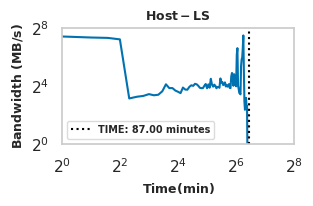

In [ ]:
df = pd.read_csv(f'/home/surbhi/measurements/linux-compile/host-ls/compile5Times/150GB/7GB-MiddleWaterMark/writes_dm0.csv', names=['writebw'])

df['writebw'] = df['writebw']/1024.0  # Convert from KB/s to MB/s
df['cumulative_gb'] = df['writebw'].cumsum() / (1024)
df.index = pd.to_timedelta(df.index, unit='s')
# 2. Resample to 1-minute ('1T') intervals
# We use different aggregation rules for your two columns:
# - 'writebw': We want the MEAN (average MB/s over that minute)
# - 'cumulative_gb': We want the MAX (the total GB reached by the end of that minute)
df_minute = df.resample('1T').mean({
    'writebw': 'mean',
    'cumulative_gb': 'max'
})
# Force the index to be numeric minutes
df_minute.index = df_minute.index.total_seconds() / 60.0
print(df_minute.index[:5])
# 3. Convert the index back to numeric minutes for easy plotting (0, 1, 2, 3...)
df_minute.index.name = 'Time (min)'
print(df_minute.index.max(), df_minute.index.max())
sns.set_theme(style="whitegrid")
plt.figure(figsize=(3, 1.5))
plt.grid(False)
print(df_minute.shape)
run_time = df_minute.index.max()
ax = sns.lineplot(x=df_minute.index, y='writebw', data=df_minute, estimator=None, errorbar=None, color=series_colors['hmls'])
ax.axvline(x=run_time, color='black', linestyle=':', label=f'TIME: {run_time:.2f} minutes')
# Create the legend with bold weight and size 11 (ideal for 5x4 plots)
ax.legend(
    prop={'weight': 'bold', 'size': 7}, 
    frameon=True, 
    edgecolor='lightgray',
    loc='lower left'
)
plt.xlabel(r'$\bf{Time (min)}$', fontsize=9, fontweight='bold')
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=9, fontweight='semibold')
plt.title(r'$\bf{Host-LS}$', fontsize=9)

plt.xscale('log', base=2)
plt.yscale('log', base=2)
# 2. Set the limit to 2^7 (128)
# We start at 1 because log2(0) is undefined
ax.set_xlim(1, 256)
ax.set_ylim(1, 256)
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')



# 3. Force ticks to appear at every power of 2
ax.xaxis.set_major_locator(ticker.LogLocator(base=2.0))


plt.savefig(f'/home/surbhi/Downloads/host-ls-kernelCompile-dm0-log.pdf', bbox_inches='tight', format="pdf")


Index([0.0, 1.0, 2.0, 3.0, 4.0], dtype='float64')
101.0 101.0
(102, 2)


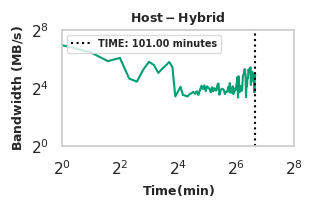

In [ ]:
df = pd.read_csv(f'/home/surbhi/measurements/linux-compile/host-hybrid/compile5Times/150GB/28GBCache/writes_dm0.csv', names=['writebw'])

df['writebw'] = df['writebw']/1024.0  # Convert from KB/s to MB/s
df['cumulative_gb'] = df['writebw'].cumsum() / (1024)
df.index = pd.to_timedelta(df.index, unit='s')
# 2. Resample to 1-minute ('1T') intervals
# We use different aggregation rules for your two columns:
# - 'writebw': We want the MEAN (average MB/s over that minute)
# - 'cumulative_gb': We want the MAX (the total GB reached by the end of that minute)
df_minute = df.resample('1T').mean({
    'writebw': 'mean',
    'cumulative_gb': 'max'
})
# Force the index to be numeric minutes
df_minute.index = df_minute.index.total_seconds() / 60.0
print(df_minute.index[:5])
# 3. Convert the index back to numeric minutes for easy plotting (0, 1, 2, 3...)
df_minute.index.name = 'Time (min)'
print(df_minute.index.max(), df_minute.index.max())
sns.set_theme(style="whitegrid")
plt.figure(figsize=(3, 1.5))
plt.grid(False)
print(df_minute.shape)
run_time = df_minute.index.max()
ax = sns.lineplot(x=df_minute.index, y='writebw', data=df_minute, estimator=None, errorbar=None, color=series_colors['hmhybrid'])
ax.axvline(x=run_time, color='black', linestyle=':', label=f'TIME: {run_time:.2f} minutes')

# Create the legend with bold weight and size 11 (ideal for 5x4 plots)
ax.legend(
    prop={'weight': 'bold', 'size': 7}, 
    frameon=True, 
    edgecolor='lightgray',
    loc='upper left'
)


plt.xlabel(r'$\bf{Time (min)}$', fontsize=9, fontweight='bold')
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=9, fontweight='bold')
plt.title(r'$\bf{Host-Hybrid}$', fontsize=9)

plt.xscale('log', base=2)
plt.yscale('log', base=2)
# 2. Set the limit to 2^7 (128)
# We start at 1 because log2(0) is undefined
ax.set_xlim(1, 256)
ax.set_ylim(1, 256)
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')

# 3. Force ticks to appear at every power of 2
ax.xaxis.set_major_locator(ticker.LogLocator(base=2.0))

plt.savefig(f'/home/surbhi/Downloads/host-hybrid-kernelCompile-dm0-log.pdf', bbox_inches='tight', format="pdf")


108.63333333333334
Index([0.0, 1.0, 2.0, 3.0, 4.0], dtype='float64')
108.0 108.0
(109, 2)


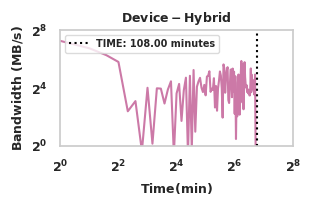

In [78]:
df = pd.read_csv(f'/home/surbhi/measurements/linux-compile/device-hybrid/compile5Times/150GB/writes_sdb.csv', names=['writebw'])

df['writebw'] = df['writebw']/1024.0  # Convert from KB/s to MB/s
df['cumulative_gb'] = df['writebw'].cumsum() / (1024)
run_time = df.index.max() / (60.0 ** 1)  # Convert seconds (index) to minutes
print(run_time)
df.index = pd.to_timedelta(df.index, unit='s')
# 2. Resample to 1-minute ('1T') intervals
# We use different aggregation rules for your two columns:
# - 'writebw': We want the MEAN (average MB/s over that minute)
# - 'cumulative_gb': We want the MAX (the total GB reached by the end of that minute)
df_minute = df.resample('1T').mean({
    'writebw': 'mean',
    'cumulative_gb': 'max'
})
# Force the index to be numeric minutes
df_minute.index = df_minute.index.total_seconds() / 60.0
print(df_minute.index[:5])
# 3. Convert the index back to numeric minutes for easy plotting (0, 1, 2, 3...)
df_minute.index.name = 'Time (min)'
print(df_minute.index.max(), df_minute.index.max())
sns.set_theme(style="whitegrid")
plt.figure(figsize=(3, 1.5))
plt.grid(False)
print(df_minute.shape)
run_time = df_minute.index.max()
ax = sns.lineplot(x=df_minute.index, y='writebw', data=df_minute, estimator=None, errorbar=None, color=series_colors['dmhybrid'])
ax.axvline(x=run_time, color='black', linestyle=':', label=f'TIME: {run_time:.2f} minutes')
# Create the legend with bold weight and size 11 (ideal for 5x4 plots)
ax.legend(
    prop={'weight': 'bold', 'size': 7}, 
    frameon=True, 
    edgecolor='lightgray',
    loc='upper left'
)
plt.xlabel(r'$\bf{Time (min)}$', fontsize=9, fontweight='bold')
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=9, fontweight='semibold')
plt.title(r'$\bf{Device-Hybrid}$', fontsize=9)

plt.xscale('log', base=2)
plt.yscale('log', base=2)
# 2. Set the limit to 2^7 (128)
# We start at 1 because log2(0) is undefined
ax.set_xlim(1, 256)
ax.set_ylim(1, 256)
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')



# 3. Force ticks to appear at every power of 2
ax.xaxis.set_major_locator(ticker.LogLocator(base=2.0))

plt.savefig(f'/home/surbhi/Downloads/device-hybrid-kernelCompile-sdb1-log.pdf', bbox_inches='tight', format="pdf")


148 2.466666666666667


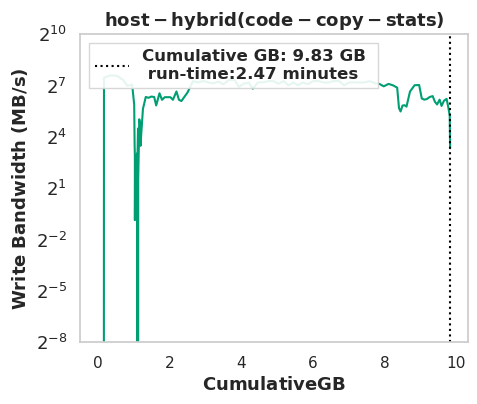

In [79]:
df = pd.read_csv(f'/home/surbhi/measurements/linux-compile/host-hybrid/code-copy-stats/writes-before.csv', names=['writebw'])

# Convert values
def convert_writebw(value):
    if 'M' in value:
        return float(value.replace('M', '')) # Just remove M
    elif 'K' in value:
        return float(value.replace('K', '')) /1024   # Convert KB to MB
    else:
        return float(value)  # Assume already in correct units

#df['writebw'] = df['writebw'].apply(convert_writebw)
df['writebw'] = df['writebw']/1024.0  # Convert from KB/s to MB/s
df['cumulative_gb'] = df['writebw'].cumsum() / (1024)
print(df.index.max(), df.index.max()/60.0)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
run_time = df.index.max() / (60.0 ** 1)  # Convert seconds (index) to minutes
#ax = sns.lineplot(x=df.index, y='writebw', data=df, estimator=None, errorbar=None, color='#FFB000')
ax = sns.lineplot(x='cumulative_gb', y='writebw', data=df, estimator=None, errorbar=None, color=series_colors['hmhybrid'])
#ax.axvline(x=df.index.max(), color='black', linestyle=':', label='TIME: ' + str(round(run_time, 2)) + ' hours')
ax.axvline(x=df['cumulative_gb'].max(), color='black', linestyle=':', label='Cumulative GB: ' + str(round(df['cumulative_gb'].max(), 2)) + ' GB \n run-time:' + str(round(run_time, 2)) + ' minutes')

# plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.xlabel(r'$\bf{Cumulative GB}$', fontsize=13, fontweight='semibold')
plt.ylabel(r'$\bf{Write~Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')
plt.title(r'$\bf{host-hybrid(code-copy-stats)}$', fontsize=13)

plt.yscale('log', base=2)
#ax.set_xscale('log', base=10)

def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -8
ax.set_ylim(lowest_power_of_2 , 2**10)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yticks(fontsize=13)

def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
#ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
#ax.set_xlim(10**0, 10**4)
#plt.xticks(common_ticks,fontsize=13)
# for xtick in common_ticks:
#     ax.plot(xtick, 0, marker='|', markersize=12, color='k',
#             transform=ax.get_xaxis_transform(), clip_on=False)

plt.legend(loc='upper left', prop={'size':12, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=12 )

plt.savefig(f'device-hybrid-compile-baseline.pdf', bbox_inches='tight', format="pdf")


101 1.6833333333333333


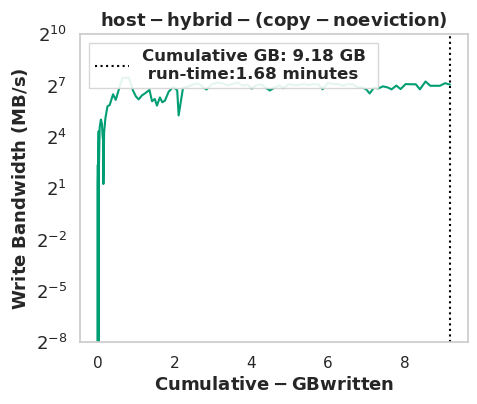

In [80]:
df = pd.read_csv(f'/home/surbhi/measurements/linux-compile/common-test/hmhybrid/write-copy1.csv', names=['writebw'])

# Convert values
def convert_writebw(value):
    if 'M' in value:
        return float(value.replace('M', '')) # Just remove M
    elif 'K' in value:
        return float(value.replace('K', '')) /1024   # Convert KB to MB
    else:
        return float(value)  # Assume already in correct units

#df['writebw'] = df['writebw'].apply(convert_writebw)
df['writebw'] = df['writebw']/1024.0  # Convert from KB/s to MB/s
df['cumulative_gb'] = df['writebw'].cumsum() / (1024)
print(df.index.max(), df.index.max()/60.0)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
run_time = df.index.max() / (60.0 ** 1)  # Convert seconds (index) to minutes
#ax = sns.lineplot(x=df.index, y='writebw', data=df, estimator=None, errorbar=None, color='#FFB000')
ax = sns.lineplot(x='cumulative_gb', y='writebw', data=df, estimator=None, errorbar=None, color=series_colors['hmhybrid'])
#ax.axvline(x=df.index.max(), color='black', linestyle=':', label='TIME: ' + str(round(run_time, 2)) + ' hours')
ax.axvline(x=df['cumulative_gb'].max(), color='black', linestyle=':', label='Cumulative GB: ' + str(round(df['cumulative_gb'].max(), 2)) + ' GB \n run-time:' + str(round(run_time, 2)) + ' minutes')

# plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.xlabel(r'$\bf{Cumulative-GB written}$', fontsize=13, fontweight='semibold')
plt.ylabel(r'$\bf{Write~Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')
plt.title(r'$\bf{host-hybrid - (copy - no eviction)}$', fontsize=13)

plt.yscale('log', base=2)
#ax.set_xscale('log', base=10)

def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -8
ax.set_ylim(lowest_power_of_2 , 2**10)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yticks(fontsize=13)

def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
#ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
#ax.set_xlim(10**0, 10**4)
#plt.xticks(common_ticks,fontsize=13)
# for xtick in common_ticks:
#     ax.plot(xtick, 0, marker='|', markersize=12, color='k',
#             transform=ax.get_xaxis_transform(), clip_on=False)

plt.legend(loc='upper left', prop={'size':12, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=12 )

plt.savefig(f'host-hybrid-compile-baseline.pdf', bbox_inches='tight', format="pdf")
